# CLASSIFICACIÓN

## **Predicción del Éxito de un Nuevo Producto en el Mercado**

Este conjunto de datos contiene información sobre distintos productos lanzados al mercado, algunos de los cuales han tenido éxito y otros no. Incluye unas 10.000 observaciones, cada una correspondiente a un producto distinto.

### **Características del Dataset**

Cada producto tiene las siguientes características:

- **id**: Identificador único del producto.  
- **category**: Categoría del producto (Electrónica, Moda, Alimentación, Juguetes, etc.).  
- **price**: Precio del producto en euros.  
- **production_cost**: Coste de fabricación del producto en euros.  
- **marketing_budget**: Presupuesto de marketing asignado en euros.  
- **pre_launch_interest**: Número de usuarios registrados en lista de espera o seguidores antes del lanzamiento.  
- **brand_reputation**: Reputación de la marca (escala de 1 a 5).  
- **competitor_count**: Número de competidores directos en el mismo segmento.  
- **social_media_mentions**: Número de menciones en redes sociales antes del lanzamiento.  
- **previous_product_success**: Porcentaje de éxito de los últimos productos de la misma marca.  
- **season**: Estación en la que se lanza el producto (Invierno, Primavera, Verano, Otoño).  
- **success**: (Variable objetivo) Indica si el producto tuvo éxito (Yes) o no (No).  

### **Variable Objetivo**

La variable `success` clasifica los productos según su rendimiento en el mercado:

- **Yes**: Productos que han tenido éxito en ventas. (1)  
- **No**: Productos que no han alcanzado las expectativas de ventas. (0)

# Fase 1: Recopilación de los datos

In [ ]:
# Importación de las bibliotecas
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, StandardScaler

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

from sklearn.metrics import accuracy_score, precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ruta = '/content/drive/MyDrive/CURSO_MACHINE_LEARNING/CSV/product_success_prediction_extended.csv'
df = pd.read_csv(ruta)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df_testing = df.sample(frac=0.15, random_state=42)
df = df.drop(df_testing.index)
df_testing_ruido = df_testing.copy()

# Fase 2: Exploración y preparación de los datos

In [ ]:
# Comprobación de que los datos se han cargado correctamente
df

,id,price,production_cost,marketing_budget,pre_launch_interest,brand_reputation,competitor_count,social_media_mentions,previous_product_success,season,category,success
1,2,1241.898030,1137.696249,21818.976063,36448.247855,3.485357,23.908083,75276.884417,0.465686,Estiu,Llar,Yes
2,3,734.702097,681.881223,23711.763088,55201.563133,3.049967,26.886697,59442.897737,0.541248,Primavera,Joguines,No
4,5,583.898901,996.140088,10936.212023,34640.168865,2.530608,23.902600,66215.993931,0.346883,Estiu,Electrònica,No
5,6,1147.707960,643.971701,34722.820802,65661.246049,3.376234,21.801501,38162.344173,0.579901,Hivern,Electrònica,Yes
6,7,669.920946,818.693296,22394.914407,48717.143856,2.992396,24.906724,61966.040634,0.467043,Hivern,Joguines,No
...,...,...,...,...,...,...,...,...,...,...,...,...
10294,7969,790.500483,939.304133,25282.623808,37369.282898,2.476669,25.436090,66420.629133,0.452734,Hivern,Moda,No
10295,6551,1243.341329,827.506341,33653.127067,60257.869672,3.685249,21.965126,54890.743072,0.634900,Primavera,Joguines,Yes
10296,7643,914.553245,905.307953,NaN,47974.780215,2.516186,20.002551,49979.438260,0.532453,Estiu,Llar,No
10297,6164,921.173530,584.787544,NaN,60348.705781,3.279107,25.328455,41644.779869,0.448033,Tardor,Joguines,Yes


In [ ]:
# Información del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8755 entries, 1 to 10299
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        8755 non-null   int64  
 1   price                     8329 non-null   float64
 2   production_cost           8755 non-null   float64
 3   marketing_budget          8322 non-null   float64
 4   pre_launch_interest       8310 non-null   float64
 5   brand_reputation          8755 non-null   float64
 6   competitor_count          8755 non-null   float64
 7   social_media_mentions     8755 non-null   float64
 8   previous_product_success  8755 non-null   float64
 9   season                    8755 non-null   object 
 10  category                  8755 non-null   object 
 11  success                   8755 non-null   object 
dtypes: float64(8), int64(1), object(3)
memory usage: 889.2+ KB


## Selección de características

In [ ]:
# Borrar id
df = df.drop('id',axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8755 entries, 1 to 10299
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   price                     8329 non-null   float64
 1   production_cost           8755 non-null   float64
 2   marketing_budget          8322 non-null   float64
 3   pre_launch_interest       8310 non-null   float64
 4   brand_reputation          8755 non-null   float64
 5   competitor_count          8755 non-null   float64
 6   social_media_mentions     8755 non-null   float64
 7   previous_product_success  8755 non-null   float64
 8   season                    8755 non-null   object 
 9   category                  8755 non-null   object 
 10  success                   8755 non-null   object 
dtypes: float64(8), object(3)
memory usage: 820.8+ KB


## Nulos

In [ ]:
# Mostramos cuántos valores nulos hay en cada columna
print(df.isnull().sum())

price                       426
production_cost               0
marketing_budget            433
pre_launch_interest         445
brand_reputation              0
competitor_count              0
social_media_mentions         0
previous_product_success      0
season                        0
category                      0
success                       0
dtype: int64


In [ ]:
# Como hay algunos valores nulos, en lugar de eliminarlos los actualizamos con su media
df.loc[:, 'price'] = df['price'].fillna(df['price'].median())
df.loc[:, 'marketing_budget'] = df['marketing_budget'].fillna(df['marketing_budget'].median())
df.loc[:, 'pre_launch_interest'] = df['pre_launch_interest'].fillna(df['pre_launch_interest'].median())

In [ ]:
print(df.isnull().sum())

price                       0
production_cost             0
marketing_budget            0
pre_launch_interest         0
brand_reputation            0
competitor_count            0
social_media_mentions       0
previous_product_success    0
season                      0
category                    0
success                     0
dtype: int64


## Únicos

In [ ]:
# Comprobación de los valores únicos en columnas de tipo object
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()}")

season: ['Estiu' 'Primavera' 'Hivern' 'Tardor']
category: ['Llar' 'Joguines' 'Electrònica' 'Aliments' 'Esports' 'Moda']
success: ['Yes' 'No']


## Duplicados

In [ ]:
# Comprobamos cuántas filas están duplicadas
print("Filas duplicadas:", df.duplicated().sum())

Filas duplicadas: 147


In [ ]:
# Eliminar duplicados manteniendo uno
df = df.drop_duplicates()

# Comprobar el número de duplicados después de la eliminación
print(f"Duplicados después de eliminar: {df.duplicated().sum()}")

Duplicados después de eliminar: 0


## Distribuciones

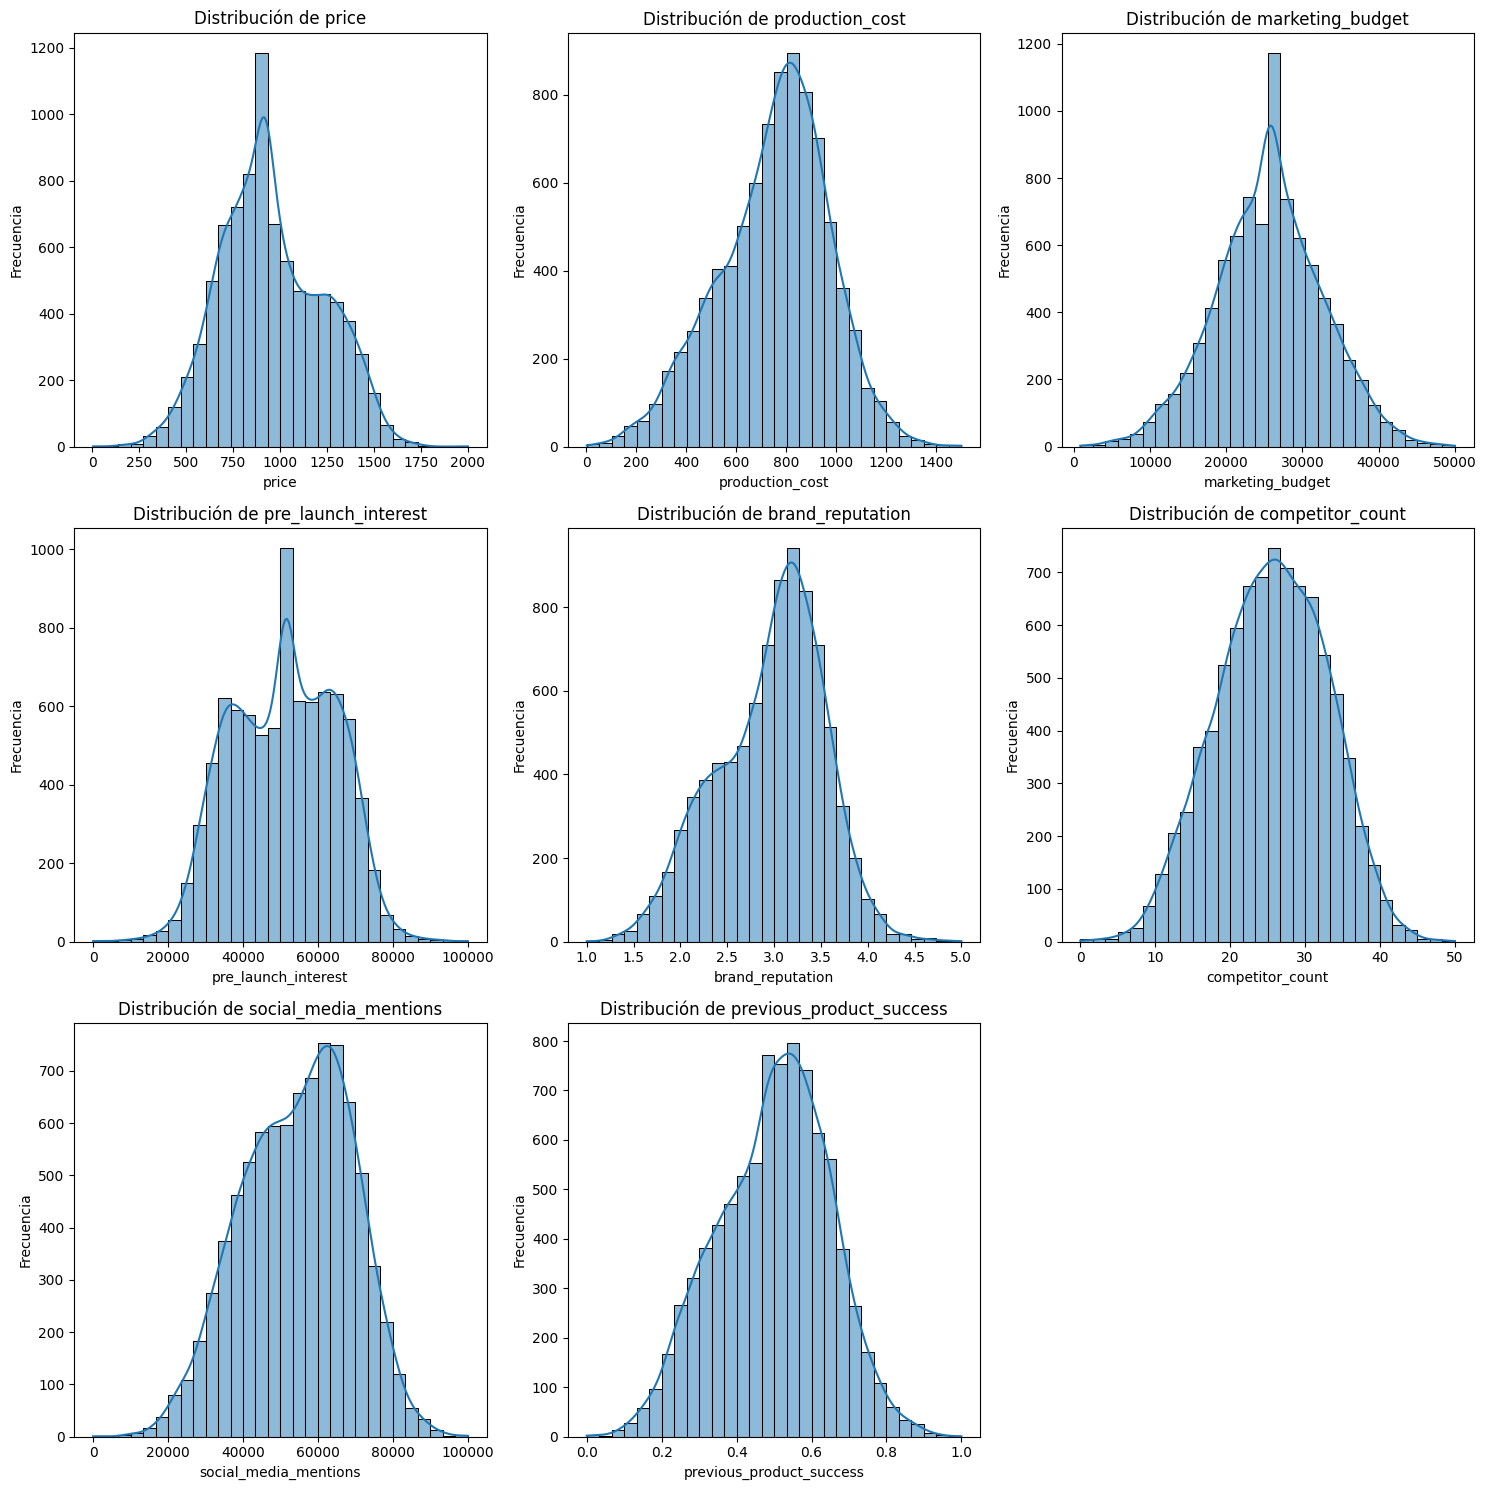

In [ ]:
"""
Si las características numéricas siguen una distribución normal, de entrada, un SVM podría ser una buena opción, así como las redes neuronales.
DT, RF y ADABOOST → no normales
"""

# Seleccionar solo las columnas numéricas de tipo int o float
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Definir el número de columnas y filas para los subplots con 3 columnas
num_cols_per_row = 3
num_rows = (len(num_cols) + num_cols_per_row - 1) // num_cols_per_row  # Calcular filas necesarias

# Crear la figura con 3 columnas
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols_per_row, figsize=(15, 5 * num_rows))

# Aplanar los ejes para facilitar la iteración
axes = axes.flatten()

# Generar histogramas para cada variable numérica
for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i])  # Histograma con línea KDE
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

# Ocultar ejes vacíos si el número de variables es impar
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


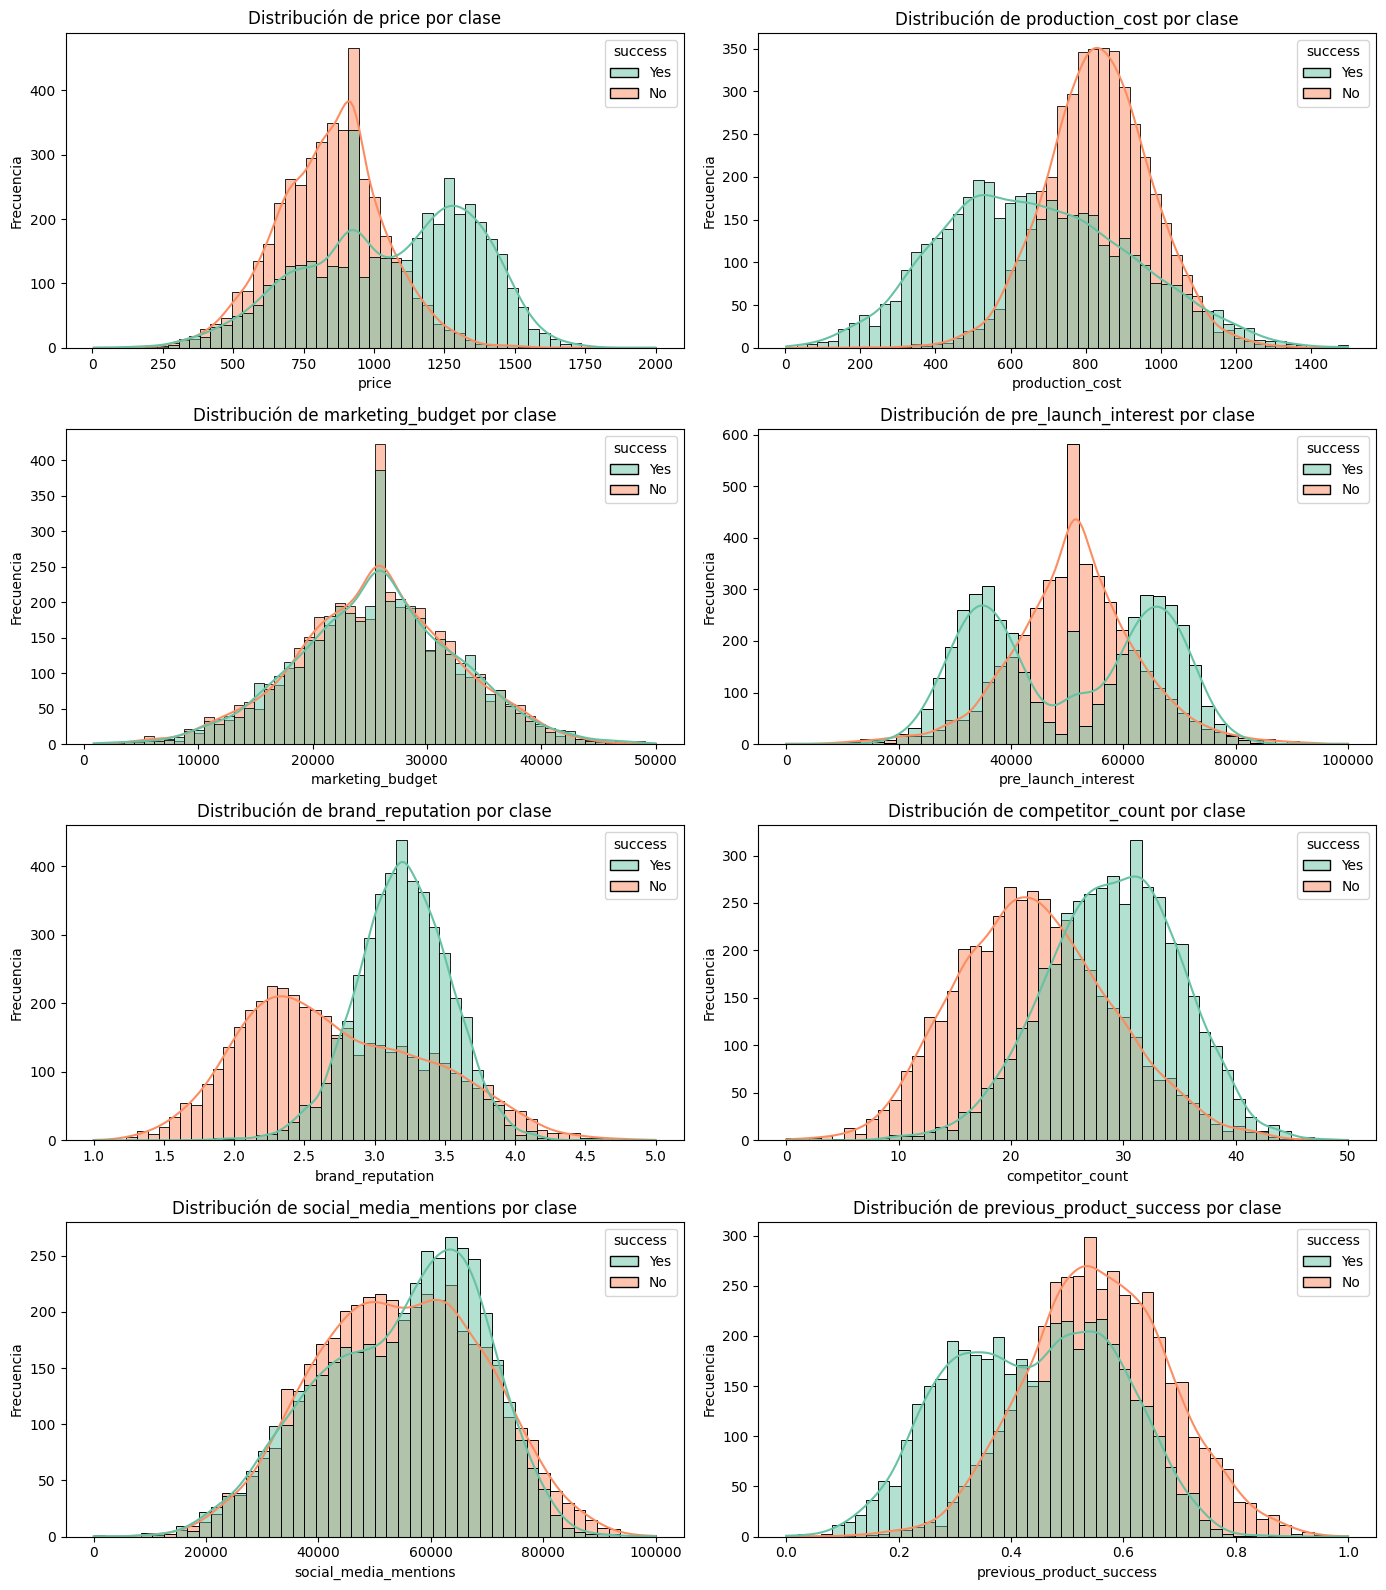

In [ ]:
# Comprovación de la distribución de los datos
"""
1. La variable más discriminativa es 'brand_reputation': los productos exitosos tienden a tener mayor reputación,
mientras que los no exitosos se concentran en valores bajos (alrededor de 2). Esta diferencia es clara y relevante.
2. En 'price', también se observa una separación: los productos con éxito suelen tener precios más altos,
mientras que los fallidos se agrupan en rangos bajos y medios. Aunque hay algo de solapamiento,
la tendencia es significativa y puede indicar una percepción de calidad o margen rentable.
Estas observaciones indican que las variables brand_reputation y price influyen de forma relevante en el éxito comercial de un producto.
"""

import math

# Filtrar columnas numéricas
caracteristicas = df.select_dtypes(include=['int64', 'float64']).columns
num_graficos = len(caracteristicas)

columnas = 2
filas = math.ceil(num_graficos / columnas)

fig, axes = plt.subplots(filas, columnas, figsize=(14, filas * 4))
axes = axes.flatten()

# Graficar distribuciones separadas por clase (Yes/No en 'success')
for i, caracteristica in enumerate(caracteristicas):
    sns.histplot(data=df, x=caracteristica, hue='success', kde=True, palette='Set2', ax=axes[i])
    axes[i].set_title(f"Distribución de {caracteristica} por clase")
    axes[i].set_xlabel(caracteristica)
    axes[i].set_ylabel("Frecuencia")

# Eliminar ejes vacíos si sobran
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Correlaciones con la variable objectivo

In [ ]:
# Convertir la variable objetivo a 0 y 1, funciona mejor para modelos de clasificación
df['success'] = df['success'].map({'Yes': 1, 'No': 0})

In [ ]:
# Mostramos la correlación entre cada variable numérica y la variable objetivo
"""
Las variables con mayor correlación positiva con el éxito del producto son la reputación de la marca,
el precio y el número de competidores directos, lo que sugiere que los productos más caros, de marcas reconocidas
y en mercados competitivos tienden a tener más éxito. Por el contrario, el coste de producción y el éxito previo
de otros productos de la misma marca muestran una correlación negativa, lo que podría indicar que fabricar más caro
o haber tenido éxito antes no garantiza un nuevo buen resultado. Otras variables como el presupuesto de marketing,
el interés previo o las menciones en redes tienen una influencia muy baja o casi nula según la correlación.
"""

correlaciones = df.select_dtypes(include=["float64", "int64"]).corr()["success"].drop("success")
print(correlaciones)

price                       0.405603
production_cost            -0.382214
marketing_budget            0.010029
pre_launch_interest        -0.032923
brand_reputation            0.412724
competitor_count            0.474942
social_media_mentions       0.007117
previous_product_success   -0.389503
Name: success, dtype: float64


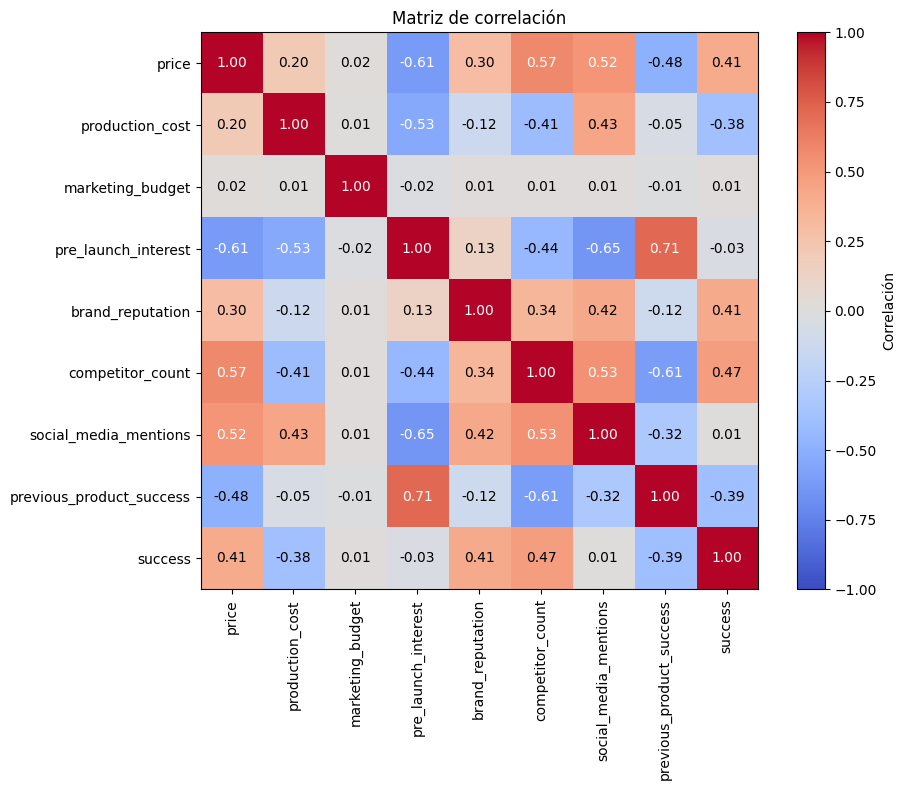

In [ ]:
# Seleccionar solo las columnas numéricas
df_numericas = df.select_dtypes(include=["float64", "int64"])

# Calcular matriz de correlación
correlation_matrix = df_numericas.corr()

# Visualización
plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, cmap="coolwarm", interpolation="none", vmin=-1, vmax=1)
plt.colorbar(label="Correlación")

cols = df_numericas.columns
plt.xticks(range(len(cols)), cols, rotation=90)
plt.yticks(range(len(cols)), cols)

for i in range(len(cols)):
    for j in range(len(cols)):
        value = correlation_matrix.iloc[i, j]
        color = 'white' if abs(value) > 0.5 else 'black'
        plt.text(j, i, f"{value:.2f}", ha='center', va='center', color=color, fontsize=10)

plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

Las tres variables con mayor correlación positiva respecto al éxito del producto son el número de competidores (0.47), la reputación de la marca (0.41) y el precio (0.41). Esto sugiere que los productos exitosos suelen pertenecer a marcas bien valoradas, tienen precios más altos y compiten en mercados activos, posiblemente más visibles o dinámicos.

Por otro lado, las correlaciones negativas más destacadas son: el éxito previo de otros productos de la marca (-0.39) y el coste de producción (-0.38). Es decir, cuanto mayor ha sido el éxito pasado de la marca, menor probabilidad de éxito en el nuevo producto, lo cual puede deberse a una fatiga de marca, expectativas demasiado altas o cambios en el mercado. Del mismo modo, un mayor coste de producción no garantiza que el producto sea mejor recibido: puede implicar sobreinversión en características que no aportan valor percibido por el consumidor.

Estas relaciones indican qué factores tienen más influencia lineal sobre el éxito y orientan qué variables pueden tener más peso predictivo en modelos supervisados.


## Equilibrio

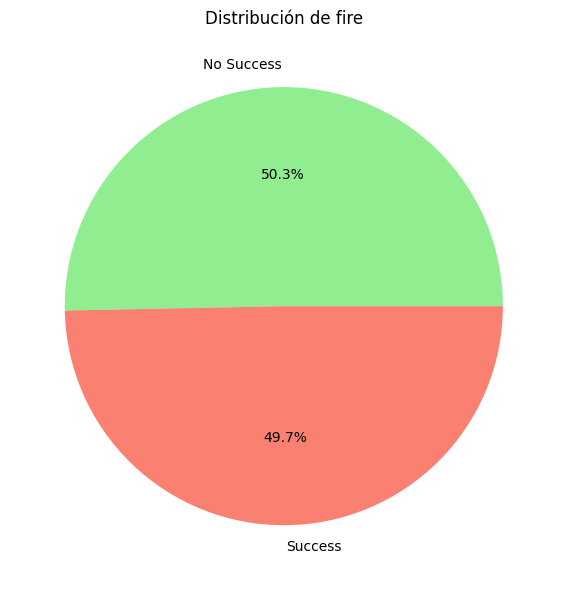

In [ ]:
plt.figure(figsize=(6, 6))
df['success'].map({0: 'No Success', 1: 'Success'}).value_counts().plot.pie(autopct='%1.1f%%', colors=['lightgreen', 'salmon'])
plt.title('Distribución de fire')
plt.ylabel("")
plt.tight_layout()
plt.show()

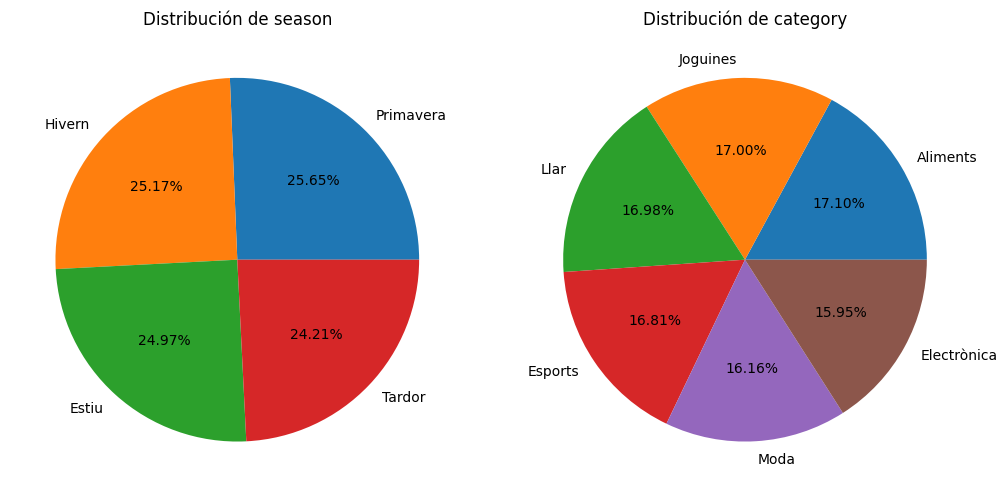

In [ ]:
# Comprobamos si las variables categóricas están equilibradas

import matplotlib.pyplot as plt

# Seleccionar las columnas categóricas (tipo 'object' o 'category')
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Configurar los gráficos en 3 columnas
num_cols_per_row = 3
num_rows = (len(cat_cols) + num_cols_per_row - 1) // num_cols_per_row  # Calcular filas necesarias

# Crear la figura con 3 columnas
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols_per_row, figsize=(15, 6 * num_rows))

# Aplanar los ejes para facilitar el recorrido
axes = axes.flatten()

# Generar gráficos de sectores para cada variable categórica
for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    labels = counts.index.astype(str)

    axes[i].pie(counts, labels=labels, autopct='%.2f%%')
    axes[i].set_title(f'Distribución de {col}')

# Ocultar ejes vacíos si hay menos categorías que subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Outliers

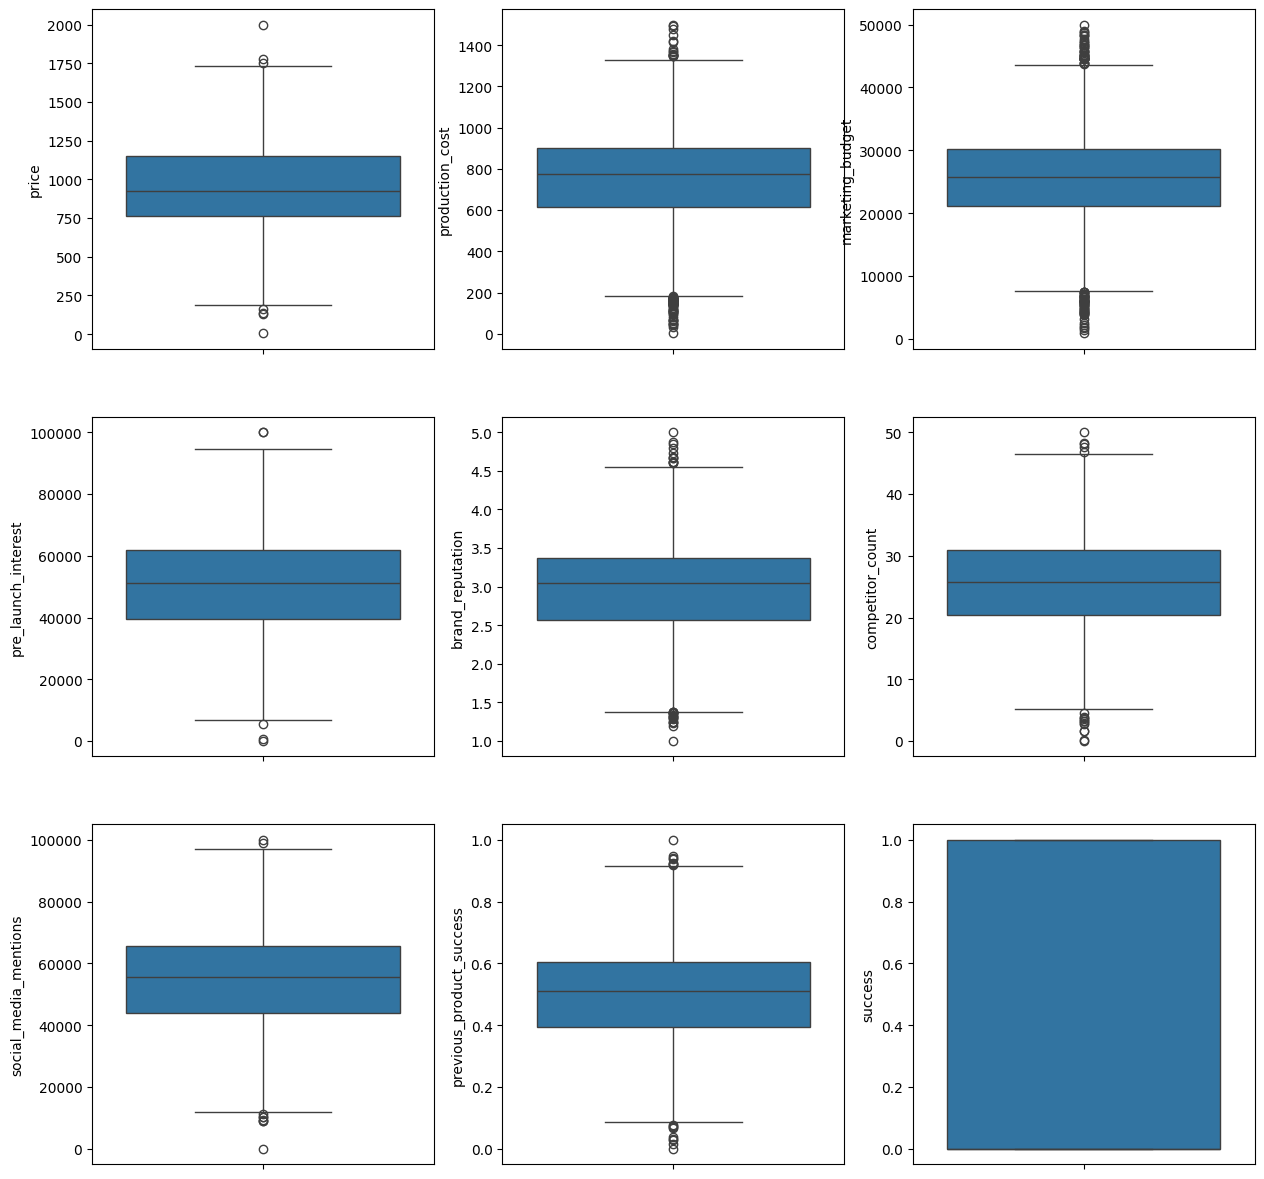

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar las columnas numéricas
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Configurar los gráficos en 3 columnas
num_cols_per_row = 3
num_rows = (len(num_cols) + num_cols_per_row - 1) // num_cols_per_row

# Crear la figura
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols_per_row, figsize=(15, 5 * num_rows))
axes = axes.flatten()

# Generar boxplots para cada variable numérica
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title

In [ ]:
# Calcular el rango intercuartílico (IQR) para cada columna numérica
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

# Contar el número de outliers por característica
outliers = ((df[num_cols] < (Q1 - 1.5 * IQR)) | (df[num_cols] > (Q3 + 1.5 * IQR))).sum()

# Mostrar el resultado
print("Número de outliers por columna:")
print(outliers)

Número de outliers por columna:
price                        7
production_cost             76
marketing_budget            97
pre_launch_interest          5
brand_reputation            29
competitor_count            17
social_media_mentions        9
previous_product_success    17
success                      0
dtype: int64


# Fase 3: División de los datos

In [ ]:
# División previa de los datos del dataframe. X serán las características e y será la columna objetivo
X = df.drop('success', axis=1)
y = df['success']

In [ ]:
# División de los datos en entrenamiento (70%) y test (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Encoders y escalado

In [ ]:
# Definir columnas categóricas y numéricas (sin incluir la variable objetivo)
cat_cols = ['category', 'season']
num_cols = ['price', 'production_cost', 'marketing_budget', 'pre_launch_interest',
            'brand_reputation', 'competitor_count', 'social_media_mentions',
            'previous_product_success']

# Inicializar escalador
scaler = StandardScaler()

# Inicializar diccionario para guardar los LabelEncoders
label_encoders = {}

# Aplicar LabelEncoder a las columnas categóricas (ajustar solo con el conjunto de entrenamiento)
for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    label_encoders[col] = le

# Aplicar StandardScaler a las columnas numéricas
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Fase 4: Entrenamiento del modelo y realización de las predicciones y Fase 5: Validación del modelo (ANNs - MLP)

Epoch 1/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8565 - loss: 0.3538 - val_accuracy: 0.9609 - val_loss: 0.1338
Epoch 2/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9549 - loss: 0.1500 - val_accuracy: 0.9648 - val_loss: 0.1200
Epoch 3/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9613 - loss: 0.1380 - val_accuracy: 0.9675 - val_loss: 0.1139
Epoch 4/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9625 - loss: 0.1311 - val_accuracy: 0.9667 - val_loss: 0.1102
Epoch 5/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9640 - loss: 0.1260 - val_accuracy: 0.9679 - val_loss: 0.1064
Epoch 6/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9649 - loss: 0.1220 - val_accuracy: 0.9698 - val_loss: 0.1031
Epoch 7/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9664 - loss: 0.1184 - val_accuracy: 0.9714 - val_loss: 0.1002
Epoch 8/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9677 - loss: 0.1148 - val_accuracy: 0.

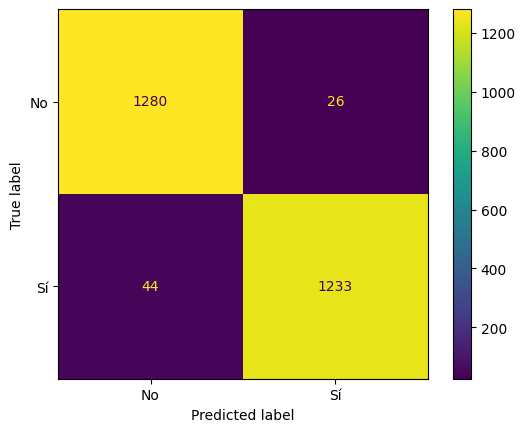

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import regularizers
import numpy as np
import random
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Fijar la semilla aleatoria para TensorFlow
valor_semilla = 42
np.random.seed(valor_semilla)
tf.random.set_seed(42)
random.seed(valor_semilla)

# Definición de la red neuronal
clasificador_MLP = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

clasificador_MLP.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenamiento del clasificador
clasificador_MLP.fit(X_train, y_train, epochs=10, batch_size=10, validation_data=(X_test, y_test))

# Realización de las predicciones
predicciones = clasificador_MLP.predict(X_test)

# Cálculo de las métricas
precision = clasificador_MLP.evaluate(X_test, y_test)
print(f'Precisión: {precision}')  # Muestra la pérdida y la precisión

# Calcular la matriz de confusión
cm = confusion_matrix(y_test, predicciones.round())  # Redondea las predicciones a 0 o 1

# Visualizar la matriz de confusión con ConfusionMatrixDisplay
# Mostrar etiquetas correctas: 0 = No, 1 = Sí
# confusion_matrix(y_true, y_pred) siempre ordena las filas y columnas según los valores únicos en y_true, en orden ascendente.
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Sí'])
disp.plot()
plt.show()

#Fase 6: Optimitzación del modelo y Fase 7: Validación del nuevo modelo (ANNs - MLP)

In [ ]:
pip install -U scikit-learn

In [ ]:
pip install -U scikeras

Mejores parámetros: {'batch_size': 32, 'epochs': 20, 'model__activation': 'relu', 'model__optimizer': 'adam'}
Mejor precisión: 0.9673021866408598


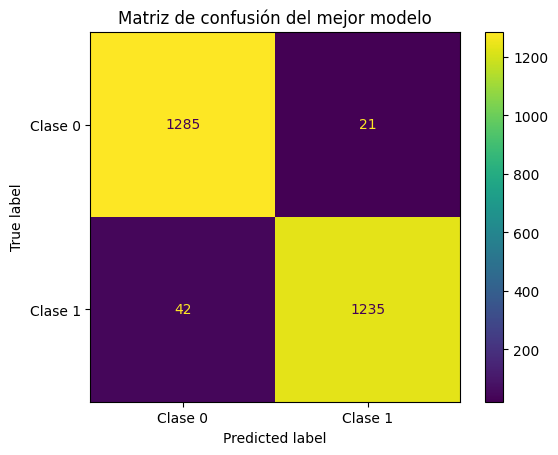

In [ ]:
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam, RMSprop
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

# Función que construye el modelo
def crear_modelo(activation='relu', optimizer='adam'):
    model = Sequential()
    model.add(Dense(64, activation=activation, input_shape=(X_train.shape[1],)))
    model.add(Dense(64, activation=activation))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Envolver el modelo con scikeras
clasificador_MLP2 = KerasClassifier(model=crear_modelo, verbose=0)

# Rejilla de hiperparámetros (usar model__ prefijo)
param_grid = {
    'epochs': [10, 20],                      # número de épocas
    'batch_size': [10, 32],                  # tamaño del lote
    'model__activation': ['relu', 'tanh'],   # función de activación
    'model__optimizer': ['adam', 'rmsprop']  # optimizador
}

# Grid search con validación cruzada
grid = GridSearchCV(estimator=clasificador_MLP2, param_grid=param_grid, cv=3)
grid_result = grid.fit(X_train, y_train)

# Resultados
print("Mejores parámetros:", grid_result.best_params_)
print("Mejor precisión:", grid_result.best_score_)

# Evaluación final
mejor_modelo = grid.best_estimator_
predicciones = mejor_modelo.predict(X_test)

# Matriz de confusión
matriz = confusion_matrix(y_test, predicciones)
disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=['Clase 0', 'Clase 1'])
disp.plot()
plt.title("Matriz de confusión del mejor modelo")
plt.show()


Epoch 1/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8139 - loss: 0.4561 - val_accuracy: 0.9443 - val_loss: 0.1607
Epoch 2/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9464 - loss: 0.1681 - val_accuracy: 0.9613 - val_loss: 0.1269
Epoch 3/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9573 - loss: 0.1447 - val_accuracy: 0.9617 - val_loss: 0.1206
Epoch 4/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9592 - loss: 0.1375 - val_accuracy: 0.9621 - val_loss: 0.1174
Epoch 5/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9607 - loss: 0.1326 - val_accuracy: 0.9644 - val_loss: 0.1143
Epoch 6/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9620 - loss: 0.1286 - val_accuracy: 0.9659 - val_loss: 0.1121
Epoch 7/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9632 - loss: 0.1253 - val_accuracy: 0.9655 - val_loss: 0.1106
Epoch 8/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9649 - loss: 0.1225 - val_accuracy:

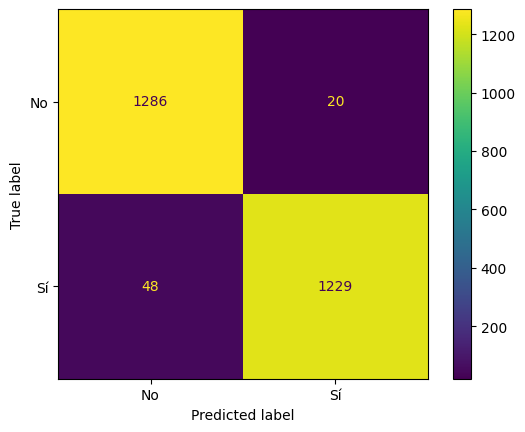

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# Fijar la semilla aleatoria para TensorFlow
valor_semilla = 42
np.random.seed(valor_semilla)
tf.random.set_seed(42)
random.seed(valor_semilla)

# Definición de la red neuronal
clasificador_MLP3 = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

clasificador_MLP3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenamiento del clasificador
clasificador_MLP3.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# Realización de las predicciones
predicciones = clasificador_MLP3.predict(X_test)

# Cálculo de las métricas
precision = clasificador_MLP3.evaluate(X_test, y_test)
print(f'Precisión: {precision}')  # Muestra la pérdida y la precisión

# Calcular la matriz de confusión
cm = confusion_matrix(y_test, predicciones.round())  # Redondea las predicciones a 0 o 1

# Visualizar la matriz de confusión con ConfusionMatrixDisplay
# Mostrar etiquetas correctas: 0 = No, 1 = Sí
# confusion_matrix(y_true, y_pred) siempre ordena las filas y columnas según los valores únicos en y_true, en orden ascendente.
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Sí'])
disp.plot()
plt.show()

# Fase 8: Conclusiones

ANNs - MLP
La diferencia del resultado de cuando se fijan manulament los parámetros a cuando no es porque Grid hace una validación cruzada y saca un promedio, por lo tanto sería más fiable.

# Fase 9: Pruebas

## Guardar el modelo ANNs - MLP

In [ ]:
import os

ruta = '/content/drive/MyDrive/CURSO_MACHINE_LEARNING/MEJORES_MODELOS/'

os.makedirs(ruta, exist_ok=True)

# Guardar modelo directamente
clasificador_MLP3.save(os.path.join(ruta, "exit.h5"))

## Cargamos el modelo ANNs -MLP

In [ ]:
from tensorflow.keras.models import load_model

# Ruta donde se guardó el modelo
ruta = '/content/drive/MyDrive/CURSO_MACHINE_LEARNING/MEJORES_MODELOS/exit.h5'

# Cargar el modelo
mejor_modelo_ANNs = load_model(ruta)

81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


Text(0.5, 1.0, 'Matriz de confusión del modelo cargado')

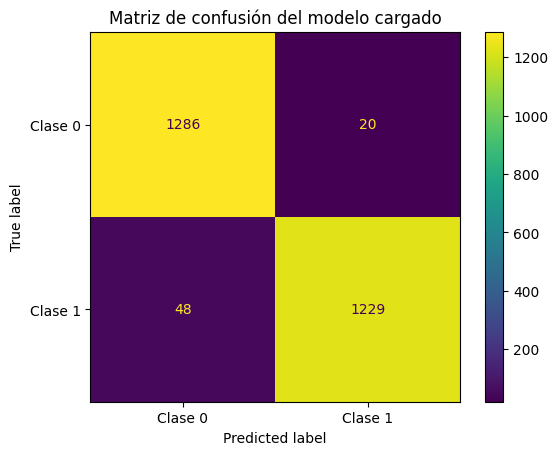

In [ ]:
# Me aseguro que sea el modelo guardado correcto
# Predecir (asegúrate de que X_test está disponible)
predicciones = mejor_modelo_ANNs.predict(X_test)
pred_clases = predicciones.round()  # Redondear si es salida sigmoide

# Matriz de confusión
cm = confusion_matrix(y_test, pred_clases)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Clase 0', 'Clase 1'])
disp.plot()
plt.title("Matriz de confusión del modelo cargado")


## Comprobación del sobreajuste ANNs - MLP

In [ ]:
# Evaluación sobre entrenamiento
y_train_pred = mejor_modelo_ANNs.predict(X_train).round()
acc_train = accuracy_score(y_train, y_train_pred)

# Evaluación sobre test
y_test_pred = mejor_modelo_ANNs.predict(X_test).round()
acc_test = accuracy_score(y_test, y_test_pred)

print(f"Precisión en entrenamiento: {acc_train:.4f}")
print(f"Precisión en test: {acc_test:.4f}")

189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Precisión en entrenamiento: 0.9720
Precisión en test: 0.9737


81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


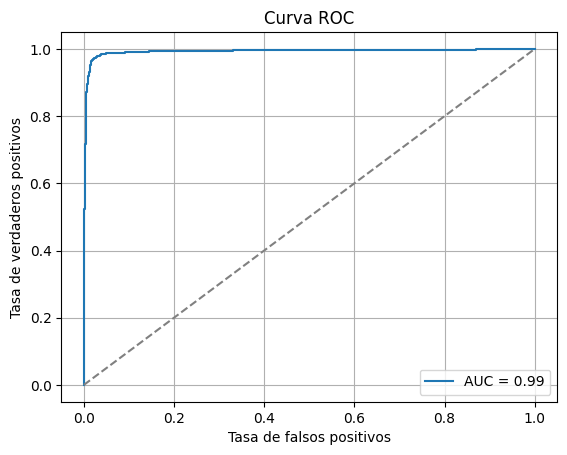

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

probs = mejor_modelo_ANNs.predict(X_test).ravel()
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC')
plt.legend()
plt.grid()
plt.show()


## ANNs - MLP (df_testing y df_testing_ruido)

49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


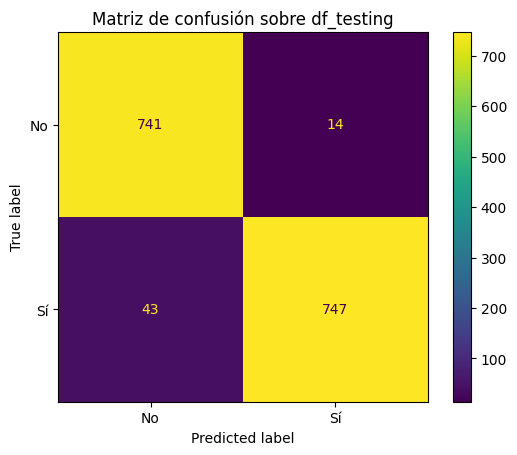

Precisión final sobre df_testing: 0.9631


In [ ]:
# Eliminar la columna 'id' si está presente
if 'id' in df_testing.columns:
    df_testing = df_testing.drop('id', axis=1)

# Rellenar valores nulos con las medianas del conjunto original
df_testing['price'] = df_testing['price'].fillna(df['price'].median())
df_testing['marketing_budget'] = df_testing['marketing_budget'].fillna(df['marketing_budget'].median())
df_testing['pre_launch_interest'] = df_testing['pre_launch_interest'].fillna(df['pre_launch_interest'].median())

# Convertir la variable objetivo a 0 y 1
df_testing['success'] = df_testing['success'].map({'Yes': 1, 'No': 0})

# Aplicar los LabelEncoders ya entrenados a las columnas categóricas
for col in cat_cols:
    le = label_encoders[col]
    df_testing[col] = le.transform(df_testing[col])

# Escalar las columnas numéricas con el StandardScaler ya ajustado
df_testing[num_cols] = scaler.transform(df_testing[num_cols])

# Separar en variables y etiquetas
X_testing = df_testing.drop('success', axis=1)
y_testing = df_testing['success']

# Predicciones del modelo
probs = mejor_modelo_ANNs.predict(X_testing).ravel()
predicciones = (probs > 0.5).astype(int)

# Matriz de confusión
matriz = confusion_matrix(y_testing, predicciones)
disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=['No', 'Sí'])
disp.plot()
plt.title("Matriz de confusión sobre df_testing")
plt.show()

# Precisión final sobre df_testing
precision_test = accuracy_score(y_testing, predicciones)
print("Precisión final sobre df_testing:", round(precision_test, 4))

49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


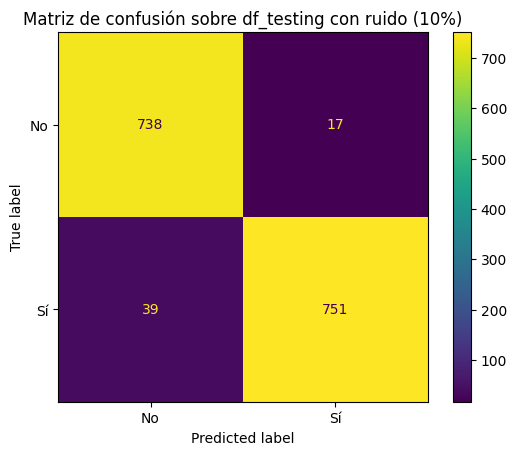

Precisión sobre df_testing con ruido: 0.9638


In [ ]:
# Eliminar la columna 'id' si está presente
if 'id' in df_testing_ruido.columns:
    df_testing_ruido = df_testing_ruido.drop('id', axis=1)

# Rellenar valores nulos con la mediana del conjunto original
df_testing_ruido['price'] = df_testing_ruido['price'].fillna(df['price'].median())
df_testing_ruido['marketing_budget'] = df_testing_ruido['marketing_budget'].fillna(df['marketing_budget'].median())
df_testing_ruido['pre_launch_interest'] = df_testing_ruido['pre_launch_interest'].fillna(df['pre_launch_interest'].median())

# Convertir la variable objetivo a 0 y 1
df_testing_ruido['success'] = df_testing_ruido['success'].map({'Yes': 1, 'No': 0})

# Aplicar los LabelEncoders ya entrenados a las columnas categóricas
for col in cat_cols:
    le = label_encoders[col]
    df_testing_ruido[col] = le.transform(df_testing_ruido[col])

# Añadir ruido a las columnas numéricas antes de escalar
np.random.seed(42)  # Para resultados reproducibles
noise_factor = 0.1  # Nivel de ruido: 10% de la desviación típica

for col in num_cols:
    std = df_testing_ruido[col].std()
    df_testing_ruido[col] += np.random.normal(0, noise_factor * std, size=df_testing_ruido.shape[0])

# Escalar las columnas numéricas usando el mismo StandardScaler
df_testing_ruido[num_cols] = scaler.transform(df_testing_ruido[num_cols])

# Separar en variables y etiquetas
X_testing_ruido = df_testing_ruido.drop('success', axis=1)
y_testing_ruido = df_testing_ruido['success']

# Predicciones con el modelo ya entrenado
probs_ruido = mejor_modelo_ANNs.predict(X_testing_ruido).ravel()
predicciones_ruido = (probs_ruido > 0.5).astype(int)

# Matriz de confusión
matriz_ruido = confusion_matrix(y_testing_ruido, predicciones_ruido)
disp = ConfusionMatrixDisplay(confusion_matrix=matriz_ruido, display_labels=['No', 'Sí'])
disp.plot()
plt.title("Matriz de confusión sobre df_testing con ruido (10%)")
plt.show()

# Precisión final con ruido
precision_ruido = accuracy_score(y_testing_ruido, predicciones_ruido)
print("Precisión sobre df_testing con ruido:", round(precision_ruido, 4))

# Nuevas predicciones

In [ ]:
# Nueva observación para predecir (esperado: No éxito)
nueva_observacion = pd.DataFrame({
    'production_cost': [777],
    'marketing_budget': [14413],
    'pre_launch_interest': [28628],
    'brand_reputation': [2],
    'competitor_count': [32],
    'social_media_mentions': [58246],
    'previous_product_success': [0.27],
    'price': [1077],
    'season': ['Primavera'],
    'category': ['Electrònica']
})

# Aplicar los LabelEncoders entrenados
for col in cat_cols:
    le = label_encoders[col]
    nueva_observacion[col] = le.transform(nueva_observacion[col])

# Escalar las columnas numéricas
nueva_observacion[num_cols] = scaler.transform(nueva_observacion[num_cols])

# Predicción con el modelo ya entrenado
prediccion = mejor_modelo_ANNs.predict(nueva_observacion)
prediccion_final = (prediccion > 0.5).astype(int)

# Mostrar resultado
print(f"Probabilidad de éxito: {prediccion[0][0]:.4f}")
print("Predicción:", "Yes (éxito)" if prediccion_final[0][0] == 1 else "No (no éxito)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Probabilidad de éxito: 0.9980
Predicción: Yes (éxito)


# PCA, ONEHOTENCODER

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8309 - loss: 0.4256 - val_accuracy: 0.9512 - val_loss: 0.1591
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9519 - loss: 0.1523 - val_accuracy: 0.9557 - val_loss: 0.1435
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9614 - loss: 0.1388 - val_accuracy: 0.9579 - val_loss: 0.1387
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9629 - loss: 0.1329 - val_accuracy: 0.9592 - val_loss: 0.1357
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9633 - loss: 0.1288 - val_accuracy: 0.9597 - val_loss: 0.1340
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9642 - loss: 0.1256 - val_accuracy: 0.9597 - val_loss: 0.1328
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9651 - loss: 0.1227 - val_accuracy

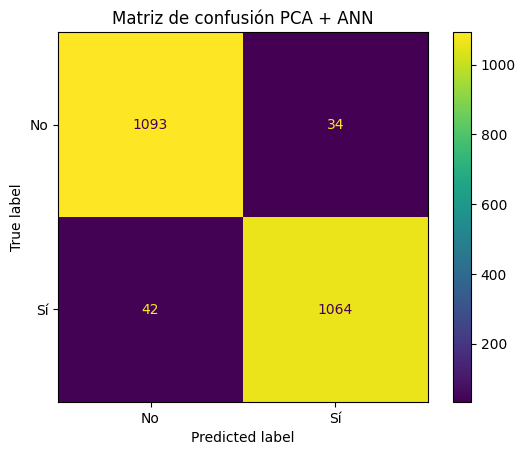

Precisión sobre X_test: 0.966


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2

# Fijar semillas
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Cargar datos
ruta = '/content/drive/MyDrive/CURSO_MACHINE_LEARNING/CSV/product_success_prediction_extended.csv'
df = pd.read_csv(ruta)

# Separar test y eliminar id
df_testing = df.sample(frac=0.15, random_state=42)
df = df.drop(df_testing.index)
df_testing_ruido = df_testing.copy()

if 'id' in df.columns:
    df = df.drop('id', axis=1)

# Rellenar nulos
df['price'] = df['price'].fillna(df['price'].median())
df['marketing_budget'] = df['marketing_budget'].fillna(df['marketing_budget'].median())
df['pre_launch_interest'] = df['pre_launch_interest'].fillna(df['pre_launch_interest'].median())

# Codificar variable objetivo
df['success'] = df['success'].map({'Yes': 1, 'No': 0})

# Columnas numéricas y categóricas
num_cols = ['price', 'production_cost', 'marketing_budget', 'pre_launch_interest',
            'brand_reputation', 'competitor_count', 'social_media_mentions',
            'previous_product_success']
cat_cols = ['category', 'season']

# Eliminar outliers
for col in num_cols:
    p1 = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)
    df = df[(df[col] >= p1) & (df[col] <= p99)]

# Separar variables y etiquetas
X = df[num_cols + cat_cols]
y = df['success']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Preprocesador
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# PCA
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_proc)
X_test_pca = pca.transform(X_test_proc)

# Red neuronal
modelo = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_pca.shape[1],)),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

modelo.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenamiento
history = modelo.fit(
    X_train_pca,
    y_train,
    validation_data=(X_test_pca, y_test),
    epochs=20,
    batch_size=32
)

# Evaluación
probs = modelo.predict(X_test_pca).ravel()
predicciones = (probs > 0.5).astype(int)

matriz = confusion_matrix(y_test, predicciones)
disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=['No', 'Sí'])
disp.plot()
plt.title("Matriz de confusión PCA + ANN")
plt.show()

print("Precisión sobre X_test:", round(accuracy_score(y_test, predicciones), 4))


In [ ]:
# Nueva observación para predecir (esperado: No éxito)
nueva_observacion = pd.DataFrame({
    'production_cost': [777],
    'marketing_budget': [14413],
    'pre_launch_interest': [28628],
    'brand_reputation': [2],
    'competitor_count': [32],
    'social_media_mentions': [58246],
    'previous_product_success': [0.27],
    'price': [1077],
    'season': ['Primavera'],
    'category': ['Electrònica']
})

# Aplicar el mismo preprocesador (escalado + OneHot)
nueva_proc = preprocessor.transform(nueva_observacion)

# Aplicar PCA
nueva_pca = pca.transform(nueva_proc)

# Hacer predicción
prediccion = modelo.predict(nueva_pca)
prediccion_final = (prediccion > 0.5).astype(int)

# Mostrar resultado
print(f"Probabilidad de éxito: {prediccion[0][0]:.4f}")
print("Predicción:", "Yes (éxito)" if prediccion_final[0][0] == 1 else "No (no éxito)")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Probabilidad de éxito: 0.1347
Predicción: No (no éxito)


In [ ]:
# Nueva observación para predecir (esperado: Sí éxito)
nueva_observacion = pd.DataFrame({
    'production_cost': [1137],
    'marketing_budget': [21818],
    'pre_launch_interest': [36448],
    'brand_reputation': [3],
    'competitor_count': [23],
    'social_media_mentions': [75276],
    'previous_product_success': [0.46],
    'price': [1241],
    'season': ['Estiu'],
    'category': ['Llar']
})

# Aplicar el mismo preprocesador (escalado + OneHot)
nueva_proc = preprocessor.transform(nueva_observacion)

# Aplicar PCA
nueva_pca = pca.transform(nueva_proc)

# Hacer predicción
prediccion = modelo.predict(nueva_pca)
prediccion_final = (prediccion > 0.5).astype(int)

# Mostrar resultado
print(f"Probabilidad de éxito: {prediccion[0][0]:.4f}")
print("Predicción:", "Yes (éxito)" if prediccion_final[0][0] == 1 else "No (no éxito)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Probabilidad de éxito: 0.9461
Predicción: Yes (éxito)


In [ ]:
for col in num_cols:
    minimo = df[col].min()
    maximo = df[col].max()
    print(f"{col}: min = {minimo}, max = {maximo}")

price: min = 385.2255871948185, max = 1544.5880471492046
production_cost: min = 214.51553423840724, max = 1219.7800471311884
marketing_budget: min = 8888.862475469288, max = 41867.06212268806
pre_launch_interest: min = 23867.80641001397, max = 77734.94126605013
brand_reputation: min = 1.6220526503538566, max = 4.07791570006663
competitor_count: min = 9.617462988077495, max = 40.13710316607108
social_media_mentions: min = 23106.04570708756, max = 81622.21634986649
previous_product_success: min = 0.1667065483773997, max = 0.7923791080429534


In [ ]:
# Nueva observación EXTREMA para predecir (esperado: No éxito)
nueva_observacion = pd.DataFrame({
    'production_cost': [1200],  # Cerca del máximo → margen bajo
    'marketing_budget': [9000],  # Cerca del mínimo
    'pre_launch_interest': [25000],  # Cerca del mínimo
    'brand_reputation': [1.7],  # Cerca del mínimo
    'competitor_count': [39],  # Cerca del máximo → competencia alta
    'social_media_mentions': [24000],  # Cerca del mínimo
    'previous_product_success': [0.18],  # Cerca del mínimo
    'price': [450],  # Cerca del mínimo → margen molt baix
    'season': ['Tardor'],
    'category': ['Llar']
})

# Aplicar el mismo preprocesador (escalado + OneHot)
nueva_proc = preprocessor.transform(nueva_observacion)

# Aplicar PCA
nueva_pca = pca.transform(nueva_proc)

# Hacer predicción
prediccion = modelo.predict(nueva_pca)
prediccion_final = (prediccion > 0.5).astype(int)

# Mostrar resultado
print(f"Probabilidad de éxito: {prediccion[0][0]:.4f}")
print("Predicción:", "Yes (éxito)" if prediccion_final[0][0] == 1 else "No (no éxito)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Probabilidad de éxito: 0.0001
Predicción: No (no éxito)


In [ ]:
# Nueva observación EXTREMA para predecir (esperado: Sí éxito)
nueva_observacion = pd.DataFrame({
    'production_cost': [220],           # Coste de producción muy bajo → mayor margen
    'marketing_budget': [41000],        # Presupuesto de marketing muy alto
    'pre_launch_interest': [77000],     # Alto interés previo al lanzamiento
    'brand_reputation': [4.0],          # Buena reputación de marca
    'competitor_count': [10],           # Poca competencia en el mercado
    'social_media_mentions': [80000],   # Alta visibilidad en redes sociales
    'previous_product_success': [0.78], # Gran éxito en productos anteriores
    'price': [1500],                    # Precio alto → mayor margen
    'season': ['Estiu'],                # Estación de lanzamiento
    'category': ['Electrònica']         # Categoría del producto
})

# Aplicar el mismo preprocesador (escalado + OneHot)
nueva_proc = preprocessor.transform(nueva_observacion)

# Aplicar PCA
nueva_pca = pca.transform(nueva_proc)

# Hacer predicción
prediccion = modelo.predict(nueva_pca)
prediccion_final = (prediccion > 0.5).astype(int)

# Mostrar resultado
print(f"Probabilidad de éxito: {prediccion[0][0]:.4f}")
print("Predicción:", "Yes (éxito)" if prediccion_final[0][0] == 1 else "No (no éxito)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Probabilidad de éxito: 0.6622
Predicción: Yes (éxito)


# Sobreajuste

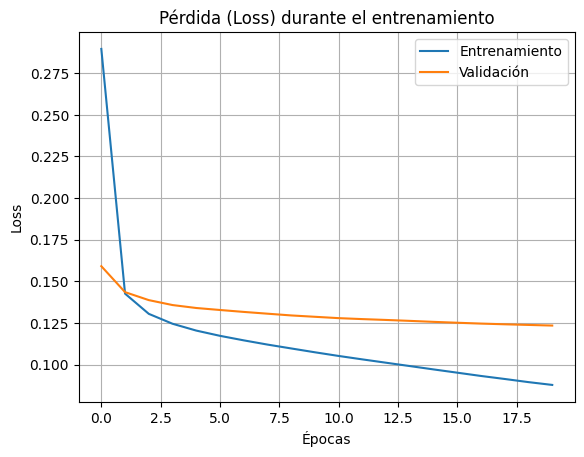

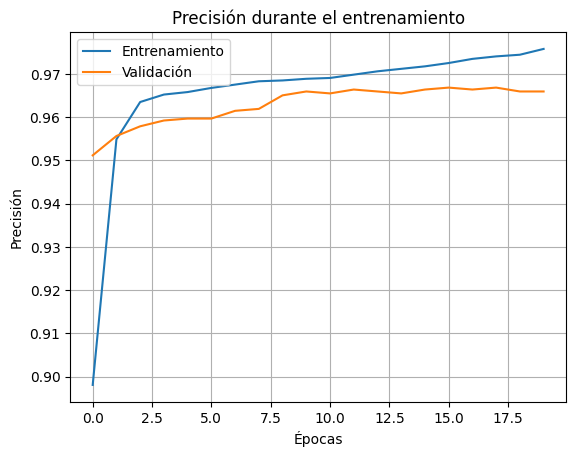

In [ ]:
"""La pérdida (loss) en el conjunto de entrenamiento disminuye progresivamente,
y la pérdida en validación también lo hace al inicio y luego se mantiene estable, sin incrementarse.

L precisión (accuracy) aumenta de forma constante tanto en entrenamiento como en validación.
La diferencia entre ambas curvas es pequeña y no se amplía con las épocas,
lo cual refuerza la idea de que el modelo tiene un buen equilibrio entre aprendizaje y generalización."""

import matplotlib.pyplot as plt

# Pérdida (loss)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida (Loss) durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Si el modelo también guarda precisión (en clasificación)
if 'accuracy' in history.history:
    plt.plot(history.history['accuracy'], label='Entrenamiento')
    plt.plot(history.history['val_accuracy'], label='Validación')
    plt.title('Precisión durante el entrenamiento')
    plt.xlabel('Épocas')
    plt.ylabel('Precisión')
    plt.legend()
    plt.grid(True)
    plt.show()


70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


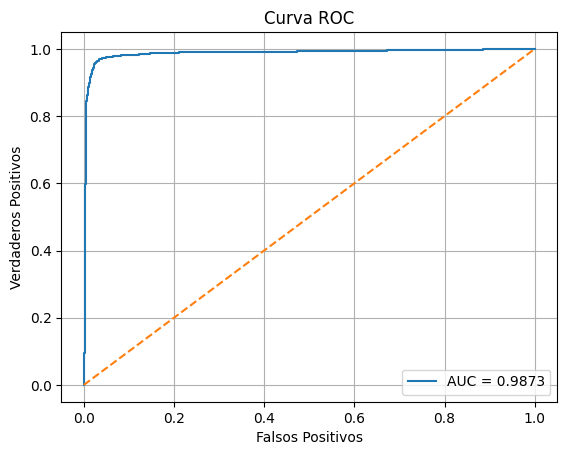

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Obtener probabilidades en lugar de clases
y_probs = modelo.predict(X_test_pca).ravel()
fpr, tpr, _ = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('Falsos Positivos')
plt.ylabel('Verdaderos Positivos')
plt.title('Curva ROC')
plt.legend()
plt.grid()
plt.show()


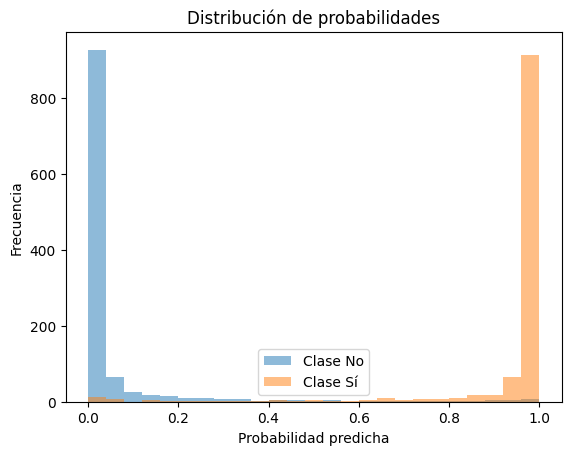

In [ ]:
plt.hist(y_probs[y_test == 0], bins=25, alpha=0.5, label='Clase No')
plt.hist(y_probs[y_test == 1], bins=25, alpha=0.5, label='Clase Sí')
plt.xlabel('Probabilidad predicha')
plt.ylabel('Frecuencia')
plt.title('Distribución de probabilidades')
plt.legend()
plt.show()

# Predicciones automáticas

In [ ]:
import pandas as pd
import numpy as np
import random

# Número de observaciones aleatorias a generar
n = 10

# Crear una lista para almacenar los resultados
resultados = []

for _ in range(n):
    # Generar valores aleatorios dentro del rango real de cada variable numérica
    nueva_obs = {col: [np.random.uniform(df[col].min(), df[col].max())] for col in num_cols}

    # Añadir columnas categóricas aleatorias basadas en valores únicos
    nueva_obs['category'] = [random.choice(df['category'].unique())]
    nueva_obs['season'] = [random.choice(df['season'].unique())]

    # Crear DataFrame de la observación
    nueva_obs_df = pd.DataFrame(nueva_obs)

    # Preprocesar y aplicar PCA
    obs_proc = preprocessor.transform(nueva_obs_df)
    obs_pca = pca.transform(obs_proc)

    # Hacer predicción
    prob = modelo.predict(obs_pca)[0][0]
    pred = "Sí (éxito)" if prob > 0.5 else "No (no éxito)"

    # Mostrar resultados uno a uno
    print(f"\nObservación generada:")
    print(nueva_obs_df.to_string(index=False))
    print(f"Probabilidad de éxito: {prob:.4f}")
    print(f"Predicción final: {pred}")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step

Observación generada:
      price  production_cost  marketing_budget  pre_launch_interest  brand_reputation  competitor_count  social_media_mentions  previous_product_success category    season
1019.060962       400.343158      40864.017905         65621.990737          3.929333         36.927272           58092.862895                  0.743498     Llar Primavera
Probabilidad de éxito: 0.7303
Predicción final: Sí (éxito)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step

Observación generada:
     price  production_cost  marketing_budget  pre_launch_interest  brand_reputation  competitor_count  social_media_mentions  previous_product_success category season
487.820472       411.530151      10380.377039          41392.41921          2.576591         17.898938           71600.591211                  0.389917 Joguines  Estiu
Probabilidad de éxito: 0.0865
Predicción final: No (no éxito)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step

Observación generada:
     price  pr